In [4]:
%run shared_imports.py

In [5]:
engine = make_engine("settings.toml")
session = Session(engine)


In [14]:
holoparasite_type_prefix = '/mob/living/simple_animal/hostile/guardian/'
holoparasite_types = {
    "gaseous": "Gaseous",
    "punch": "Standard",
    "ranged": "Ranged",
    "healer": "Support",
    "bomb": "Explosive",
    "assassin": "Assassin",
    "beam": "Lightning",
    "charger": "Charger",
    "protector": "Protector"
}

In [8]:
query = session.query(Feedback).join(Round).filter(
        Feedback.key_name=='guardian_pick',
        Round.start_datetime >= datetime(2023, 7, 1))

In [15]:
df = pd.read_sql_query(
    query.statement,
    session.connection()
)

In [11]:
df

,id,datetime,round_id,key_name,key_type,version,json
0,479988,2023-07-01 02:19:22,36359,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
1,479106,2023-07-02 17:54:50,36384,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
2,479064,2023-07-02 19:21:21,36385,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
3,478833,2023-07-03 03:54:43,36391,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
4,478545,2023-07-03 20:04:38,36398,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
...,...,...,...,...,...,...,...
670,465566,2024-08-03 15:42:43,41316,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
671,467740,2024-08-04 05:39:04,41322,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
672,467374,2024-08-04 19:08:16,41329,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...
673,467314,2024-08-04 21:26:46,41330,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...


In [17]:
def json_to_series(text):
    
    keys, values = zip(*[(k.replace(holoparasite_type_prefix, ''), v) for k, v in text['data'].items()])
    return pd.Series(values, index=keys)

df = pd.concat([df, df['json'].apply(json_to_series)], axis=1)

df['month'] = df.datetime.dt.month
df['day'] = df.datetime.dt.day
df['year'] = df.datetime.dt.year

In [18]:
df

,id,datetime,round_id,key_name,key_type,version,json,charger,fire,ranged,healer,punch,beam,protector,assassin,bomb,gaseous,month,day,year
0,479988,2023-07-01 02:19:22,36359,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,1,2023
1,479106,2023-07-02 17:54:50,36384,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2,2023
2,479064,2023-07-02 19:21:21,36385,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,2,2023
3,478833,2023-07-03 03:54:43,36391,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3,2023
4,478545,2023-07-03 20:04:38,36398,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,3,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,465566,2024-08-03 15:42:43,41316,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8,3,2024
671,467740,2024-08-04 05:39:04,41322,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,8,4,2024
672,467374,2024-08-04 19:08:16,41329,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,2.0,NaN,1.0,1.0,NaN,NaN,NaN,NaN,8,4,2024
673,467314,2024-08-04 21:26:46,41330,guardian_pick,tally,1,{'data': {'/mob/living/simple_animal/hostile/g...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,8,4,2024


In [22]:
data = dict()
for holopara_type in holoparasite_types.keys():
    datum = df.groupby(['month', 'year'], as_index=False)[holopara_type].sum().astype(int)
    datum['dt']= pd.to_datetime(datum.year.astype(str) + datum.month.astype(str), format='%Y%m')
    data[holopara_type] = datum


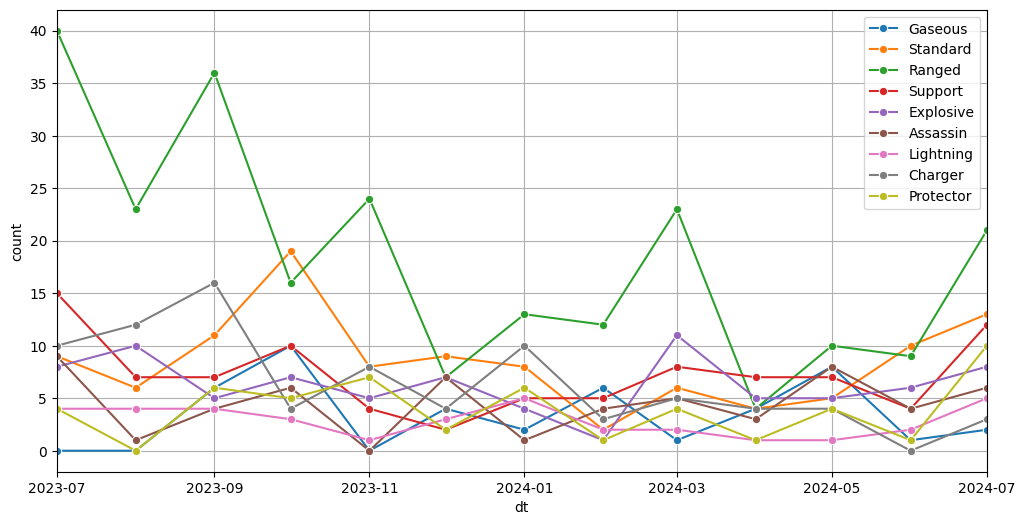

In [38]:
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
for holopara_type, datum in data.items():
    sns.lineplot(data=datum, x='dt', y=holopara_type, marker='o', label=holoparasite_types[holopara_type])

ax.set(ylabel='count')
plt.grid()
plt.xlim(date(2023, 7, 1), date(2024, 7, 1))
plt.savefig('paras.png')

In [9]:
plt.savefig('vamp.png')

<Figure size 640x480 with 0 Axes>

In [21]:
session.query(Feedback).join(Round).filter(
        Feedback.key_name=='vampire_subclasses',
        Round.start_datetime >= datetime.datetime(2023, 7, 1)).order_by(asc(Round.start_datetime)).all()[0].round

<Round#36664 [2023-07-24] traitor_vampire/Cyberiad>